In [1]:
import numpy as np
from numpy import random
import pandas as pd
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm


#from gdpc import __url__, Editor, Block

#editor = Editor(buffering=True)

sub_grid_init = np.loadtxt("grav_test_sf.csv",delimiter=" ", dtype=object)

sub_grid = sub_grid_init.reshape((200, 200, 44))
sub_grid = np.flip(sub_grid,axis=2)

In [3]:
all_blocks = np.unique(sub_grid)
print(all_blocks)

['0' 'minecraft:diamond_ore' 'minecraft:dirt' 'minecraft:gold_ore'
 'minecraft:iron_ore' 'minecraft:stone']


In [4]:

unique, counts = np.unique(sub_grid, return_counts=True)

dict(zip(unique, counts))


{'0': np.int64(35200),
 'minecraft:diamond_ore': np.int64(2193),
 'minecraft:dirt': np.int64(156382),
 'minecraft:gold_ore': np.int64(4747),
 'minecraft:iron_ore': np.int64(7155),
 'minecraft:stone': np.int64(1554323)}

In [ ]:
#replacing minecraft block names with density values

density_grid = np.empty(shape = (200, 200, 44))
for x in range(0,200):
    for z in range(0,200):
        for y in range(0,44):
            if sub_grid[x,z,y] == "minecraft:grass_block[snowy=false]":
                density_grid[x,z,y] = 1300
            if sub_grid[x,z,y] in ("minecraft:water[level=0]", 
                                   "minecraft:water[level=1]",
                                   "minecraft:water[level=2]",
                                   "minecraft:water[level=3]",
                                   "minecraft:water[level=4]",
                                   "minecraft:water[level=5]",
                                   "minecraft:water[level=6]",
                                   "minecraft:water[level=7]",
                                   "minecraft:water[level=8]"):
                density_grid[x,z,y] = 1000
            if sub_grid[x,z,y] == "minecraft:air":
                density_grid[x,z,y] = 1.23
            if sub_grid[x,z,y] == "minecraft:dirt":
                density_grid[x,z,y] = 1300
            if sub_grid[x,z,y] == "minecraft:sand":
                density_grid[x,z,y] = 1400
            if sub_grid[x,z,y] == "minecraft:gravel":
                density_grid[x,z,y] = 1600
            if sub_grid[x,z,y] == "minecraft:clay":
                density_grid[x,z,y] = 1400
            if sub_grid[x,z,y] == "minecraft:stone":
                density_grid[x,z,y] = 2400
            if sub_grid[x,z,y] == "minecraft:diorite":
                density_grid[x,z,y] = 2700
            if sub_grid[x,z,y] == "minecraft:granite":
                density_grid[x,z,y] = 2400
            if sub_grid[x,z,y] == "minecraft:andesite":
                density_grid[x,z,y] = 2400
            if sub_grid[x,z,y] == "minecraft:coal_ore":
                density_grid[x,z,y] = 1300
            if sub_grid[x,z,y] == "minecraft:emerald_ore":
                density_grid[x,z,y] = 5000
            if sub_grid[x,z,y] == "minecraft:lapis_ore":
                density_grid[x,z,y] = 5000
            if sub_grid[x,z,y] == "minecraft:iron_ore":
                density_grid[x,z,y] = 10000
            if sub_grid[x,z,y] == "minecraft:gold_ore":
                density_grid[x,z,y] = 20000
            if sub_grid[x,z,y] == "minecraft:diamond_ore":
                density_grid[x,z,y] = 10000
            else:
                density_grid[x,z,y] = 1.23


Attempting a faster way using density grid with only ore bodies??

In [3]:
density_grid = np.zeros(shape = (200, 200, 44))
for x in range(0,200):
    for z in range(0,200):
        for y in range(0,44):
            if sub_grid[x,z,y] == "minecraft:iron_ore":
                density_grid[x,z,y] = 6000
            if sub_grid[x,z,y] == "minecraft:gold_ore":
                density_grid[x,z,y] = 7000
            if sub_grid[x,z,y] == "minecraft:diamond_ore":
                density_grid[x,z,y] = 6000


In [10]:
ore_id = np.sum(density_grid, axis=2)

In [11]:
ore_id.shape

(200, 200)

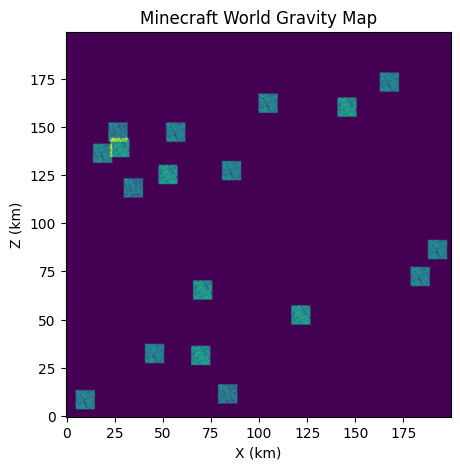

In [14]:
fig = plt.figure(figsize=(6,5))
plt.imshow(ore_id,origin='lower')
#plt.contourf(x_obs, y_obs, gz_mgal, 50, cmap='hsv')
#plt.colorbar(label='Gravity anomaly (mGal)')
plt.xlabel('X (km)')
plt.ylabel('Z (km)')
plt.title('Minecraft World Gravity Map')
plt.show()

In [5]:
density_grid[:,0,:].shape

(200, 44)

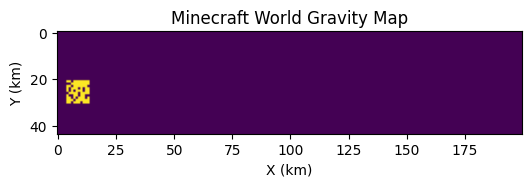

In [8]:
fig = plt.figure(figsize=(6,5))
plt.imshow(density_grid[:,10,:].T)
#plt.contourf(x_obs, y_obs, gz_mgal, 50, cmap='hsv')
#plt.colorbar(label='Gravity anomaly (mGal)')
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.title('Minecraft World Gravity Map')
plt.show()

In [ ]:
density_grid_b = np.ones(shape = (1000, 1000, 44))
for x in range(0,1000):
    for y in range(0,1000):
        for z in range(0,44):
            if z<5:
                density_grid_b[x,y,z]=1300
            else:
                density_grid_b[x,y,z]=2400

In [ ]:
for x in range(400,600):
    for y in range(400,600):
        for z in range(0,44):
            density_grid_b[x,y,z]=sub_grid[x-400,y-400,z]

In [ ]:
d_grid_test = np.ones(shape = (200, 200, 55))
d_grid_test = d_grid_test*1000
d_grid_test[100:120,100:120,20:30]=1500

In [45]:
G = 6.674e-11  # gravitational constant, m^3/kg/s^2

nx, ny, nz = 200, 200, 44 #number of cells
dx = dy = dz = 1  # cell size in meters

nx_obs, ny_obs, nz_obs = 200, 200, 1
dx_obs = dy_obs = 1

# Coordinates of cell centers
x = (np.arange(nx)) * dx + 0.5
y = (np.arange(ny)) * dy + 0.5
z = np.arange(0, -nz, -dz) - 0.5  # depth increasing downward

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Observation grid
x_o = (np.arange(nx_obs)) * dx_obs + 0.5
y_o = (np.arange(ny_obs)) * dy_obs + 0.5

x_obs, y_obs = np.meshgrid(x_o, y_o, indexing='ij')
z_obs = 0.0

# Compute gravity at each observation point
gz = np.zeros_like(x_obs,dtype=float)
for i in range(nx):
    for j in range(ny):
        for k in range(nz):
           rx = x_obs - X[i,j,k]
           ry = y_obs - Y[i,j,k]
           rz = 0 - Z[i,j,k]
           r3 = (rx**2 + ry**2 + rz**2)**1.5
           gz += G * density_grid[j,i,k] * dz * dy * dx * rz / r3

# Convert to mGal
gz_mgal = gz * 1e8

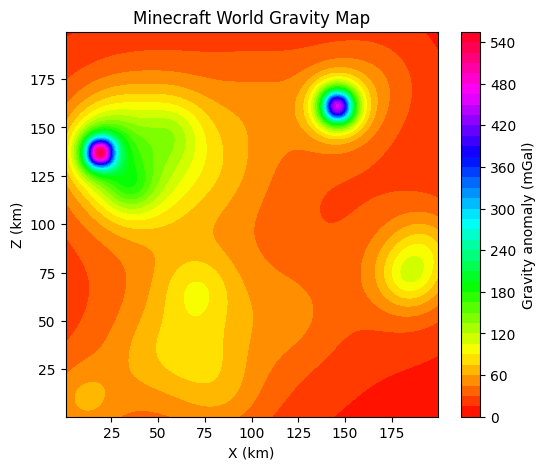

In [54]:
fig = plt.figure(figsize=(6,5))
plt.contourf(x_obs, y_obs, gz_mgal, 50, cmap='hsv')
plt.colorbar(label='Gravity anomaly (mGal)')
plt.xlabel('X (km)')
plt.ylabel('Z (km)')
plt.title('Minecraft World Gravity Map')
plt.show()
fig.savefig('ore_only_test.png')

In [48]:
np.savetxt('grav_grid.txt',gz_mgal, delimiter=' ')

In [53]:
np.max(grav_grid)

np.float64(541.6274098652866)

In [25]:
d_grid_test = np.ones(shape = (1000, 1000, 30))
d_grid_test = d_grid_test*1000
d_grid_test[560:570,520:530,20:25]=1500

In [20]:
G = 6.674e-11  # gravitational constant, m^3/kg/s^2

nx, ny, nz = 200, 200, 44 #number of cells
dz = 1  # cell size in meters
dx = dy = 1

nx_obs, ny_obs, nz_obs = 50, 50, 1
dx_obs = dy_obs = 4

# Coordinates of cell centers
x = (np.arange(nx)) * dx + 0.5
y = (np.arange(ny)) * dy + 0.5
z = np.arange(0, -nz, -dz) - 0.5  # depth increasing downward

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Observation grid
x_o = (np.arange(nx_obs)) * dx_obs + 2
y_o = (np.arange(ny_obs)) * dy_obs + 2

x_obs, y_obs = np.meshgrid(x_o, y_o, indexing='ij')
z_obs = 0.0


In [21]:
#calculating the distance between any two points of the observation grid and model
def radius(a,b,i,j,k):
    rx = x_obs[a,b] - X[i,j,k]
    ry = y_obs[a,b] - Y[i,j,k]
    rz = 0 - Z[i,j,k]
    r3 = (rx**2 + ry**2 + rz**2)**1.5
    return r3

In [22]:
def gravity(a,b):
    gz = 0
    for i in range(nx):
        for j in range(ny):
            for k in range(nz):
                rz = Z[i,j,k]
                gz += ((G * density_grid[i,j,k] * dz * dy * dx * rz) / radius(a,b,i,j,k))*1e8
    return(gz)


In [23]:
grav_grid = np.zeros((50,50))
for a in range(nx_obs):
    for b in range(ny_obs):
        grav_grid[a,b] = gravity(a,b)

KeyboardInterrupt: 

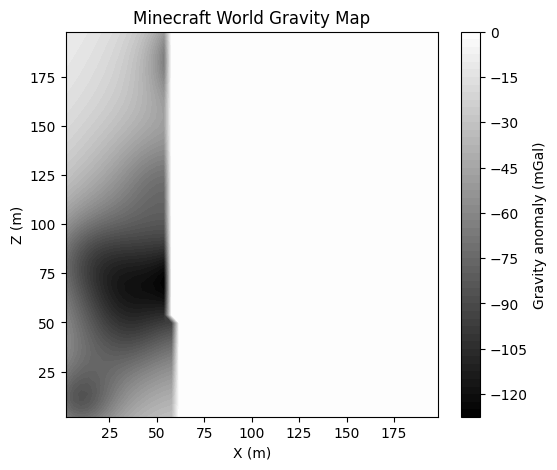

In [19]:
fig = plt.figure(figsize=(6,5))
plt.contourf(x_obs, y_obs, grav_grid, 50, cmap='gray')
plt.colorbar(label='Gravity anomaly (mGal)')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.title('Minecraft World Gravity Map')
plt.show()
fig.savefig('ore_only_test_2.png')

In [ ]:
img = Image.open("ore_only_test.png")
img = img.convert('RGB')

# Resize smoothly down to 32x32 pixels
img = img.resize((200,200), resample=Image.Resampling.NEAREST)

arr = np.array(img)
arr = arr[:,:,:3]
arr = np.sum(arr,axis=2)